<a href="https://colab.research.google.com/github/Carmen10-171/01MIAR_ABR26/blob/main/01MIAR_ACT_Dataset_Calidad_aire_AM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="viu_logo.png" width="200">

# 01MIAR - Actividad Dataset
Autor: Mª Carmen Copé Soler


#### 1. Dataset escogido y objetivos del estudio

Esta actividad contiene información sobre la calidad del aire obteniendo el análisis y tratamiento de datos con un dataset de Madrid Open Data desde del portal de datos abiertos del Ayuntamiento de Madrid con los datos diarios desde 2001

En esta actividad se trabaja con un conjunto de datos del Portal de datos abiertos del Ayuntamiento de Madrid. El objetivo es aplicar técnicas de carga, exploración, limpieza, análisis y visualización utilizando Python, NumPy, Pandas, Matplotlib y Seaborn.

Se ha elegido el conjunto de datos "Calidad del aire. Datos diarios desde 2001", ya que permite realizar un análisis interesante sobre información medioambiental pública de la ciudad de Madrid.

Portal oficial del dataset:
https://datos.madrid.es/egob/catalogo/201410-0-calidad-aire-diario




![image.png](attachment:04012f3f-ae48-4a8f-8f30-82d50e701710.png)


El objetivo principal es explorar, limpiar y analizar los datos diarios de calidad del aire de Madrid para identificar patrones, valores ausentes, distribuciones y relaciones entre variables numéricas.

Además intentamos resolver:

- Describir la estructura del fichero
- Evaluar la calidad del dato
- Representar visualmente distribuciones y posibles relaciones
- Obtener una conclusión crítica sobre el proceso de tratamiento de datos.


#### 2. Lectura y merge de varios ficheros

In [1]:
# ============================================
# 1. IMPORTS
# ============================================
import re
import io
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from urllib.parse import urljoin
from io import BytesIO

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')

#### 3. Preparación del dataset
## Localización automática del recurso de descarga
El portal de Madrid Open Data publica diferentes recursos por anualidades. En lugar de fijar manualmente una URL concreta, se intenta localizar automáticamente un recurso descargable (CSV o ZIP) desde la página oficial del dataset.

> **Nota:** Si el scraping del portal cambiase y no encontrara el recurso automáticamente, se puede descargar manualmente uno de los ficheros desde la página oficial y cargarlo desde local.



In [2]:
# ============================================
# 3. DESCARGA DEL HTML DE LA PÁGINA
# ============================================
#server_url = 'https://datos.madrid.es/egob/catalogo/201410-0-calidad-aire-diario'

server_url = 'https://datos.madrid.es/dataset/201410-0-calidad-aire-diario/resource/201410-4-calidad-aire-diario-csv?view=table'

resp = requests.get(server_url, timeout=30)
resp.raise_for_status()
html = resp.text
print("HTML descargado correctamente:", len(html), "caracteres")


HTML descargado correctamente: 209843 caracteres


#### 4. Extracción de posibles enlaces de descarga

In [3]:
# ============================================
# 4. EXTRACCIÓN DE ENLACES REALES DE DATOS
# ============================================
soup = BeautifulSoup(html, 'html.parser')
links = []
for a in soup.find_all('a', href=True):
    href = urljoin(server_url, a['href'])
    if any(ext in href.lower() for ext in ['csv', 'zip', 'json', 'xml']):
        links.append(href)

# También buscamos URLs que pudieran venir embebidas en scripts o texto
extra_links = re.findall(r'https?://[^\s"\<>]+', html)
for u in extra_links:
    if any(ext in u.lower() for ext in ['csv', 'zip', 'json', 'xml']):
        links.append(u)

links = sorted(set(links))
recursos = pd.DataFrame({'url_recurso': links})
recursos.head(20)



,url_recurso
0,https://datos.madrid.es/api/3/action/datastore...
1,https://datos.madrid.es/api/3/action/datastore...
2,https://datos.madrid.es/api/3/action/datastore...
3,https://datos.madrid.es/api/3/action/datastore...
4,https://datos.madrid.es/api/3/action/datastore...
5,https://datos.madrid.es/dataset/201410-0-calid...
6,https://datos.madrid.es/dataset/201410-0-calid...
7,https://datos.madrid.es/dataset/201410-0-calid...
8,https://datos.madrid.es/dataset/201410-0-calid...
9,https://datos.madrid.es/dataset/201410-0-calid...


In [4]:
# ============================================
# 5. SELECCIÓN AUTOMÁTICA DEL RECURSO
# ============================================
resource_url = None

csv_links = [u for u in links if '.csv' in u.lower()]
zip_links = [u for u in links if '.zip' in u.lower()]

# Preferencia por recursos recientes (2026 o 2025) si aparecen en el texto de la URL
for year in ['2026', '2025', '2024', '2023']:
    candidates = [u for u in csv_links if year in u]
    if candidates:
        resource_url = candidates[0]
        break

if resource_url is None and csv_links:
    resource_url = csv_links[0]

if resource_url is None:
    for year in ['2026', '2025', '2024', '2023']:
        candidates = [u for u in zip_links if year in u]
        if candidates:
            resource_url = candidates[0]
            break

if resource_url is None and zip_links:
    resource_url = zip_links[0]

print('Recurso seleccionado automáticamente:')
print(resource_url)
print("Número de enlaces encontrados:", len(zip_links))
for u in zip_links:
    print(u)



Recurso seleccionado automáticamente:
https://datos.madrid.es/dataset/201410-0-calidad-aire-diario/resource/201410-4-calidad-aire-diario-csv/download/201410-4-calidad-aire-diario-csv.csv
Número de enlaces encontrados: 0


In [5]:
# ============================================
# 6. DESCARGA Y LECTURA DEL RECURSO
# ============================================
if not resource_url:
    raise ValueError("No se encontró ningún recurso descargable válido.")

r = requests.get(resource_url, timeout=60)
r.raise_for_status()
content = r.content

# --- CORRECCIÓN IMPORTANTE ---
# Eliminar BOM UTF-8 si existe (muy común en datos.madrid.es)
content = content.lstrip(b"\xef\xbb\xbf")

# Si fuera ZIP (no suele ocurrir en datos.madrid.es)
if resource_url.lower().endswith('.zip'):
    zf = zipfile.ZipFile(BytesIO(content))
    print("Ficheros dentro del ZIP:", zf.namelist()[:10])

    inner_name = next(
        (name for name in zf.namelist() if name.lower().endswith(('.csv', '.txt'))),
        None
    )
    if inner_name is None:
        raise ValueError("No se encontró CSV/TXT dentro del ZIP.")

    with zf.open(inner_name) as f:
        raw = f.read()

    # --- CORRECCIÓN ---
    # Forzar lectura con separador ';' y BOM eliminado
    df = pd.read_csv(BytesIO(raw.lstrip(b"\xef\xbb\xbf")), sep=";", encoding="utf-8-sig")
    encoding_used = "utf-8-sig"
    sep_used = ";"

else:
    # --- CORRECCIÓN ---
    # Forzar lectura directa del CSV con separador ';'
    df = pd.read_csv(BytesIO(content), sep=";", encoding="utf-8-sig")
    encoding_used = "utf-8-sig"
    sep_used = ";"

# ============================================
# 7. INFORMACIÓN DEL DATASET
# ============================================
print("Codificación detectada:", encoding_used)
print("Separador detectado:", repr(sep_used))
print("Dimensiones del dataset:", df.shape)

df.head()

Codificación detectada: utf-8-sig
Separador detectado: ';'
Dimensiones del dataset: (1411, 69)


,PROVINCIA,MUNICIPIO,ESTACION,MAGNITUD,PUNTO_MUESTREO,ANO,MES,D01,V01,D02,V02,D03,V03,D04,V04,D05,V05,D06,V06,D07,V07,D08,V08,D09,V09,D10,V10,D11,V11,D12,V12,D13,V13,D14,V14,D15,V15,D16,V16,D17,V17,D18,V18,D19,V19,D20,V20,D21,V21,D22,V22,D23,V23,D24,V24,D25,V25,D26,V26,D27,V27,D28,V28,D29,V29,D30,V30,D31,V31
0,28,79,4,6,28079004_6_48,2024,1,0.5,V,0.6,V,0.4,V,0.4,V,0.3,V,0.4,V,0.5,V,0.6,V,0.4,V,0.4,V,0.5,V,0.5,V,0.6,V,0.6,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.4,V,0.5,V,0.6,V,0.7,V,0.9,V,0.9,V,0.9,V,0.6,V,0.5,V,0.6,V,0.7,V,0.7,V
1,28,79,4,6,28079004_6_48,2024,2,0.6,V,0.5,V,0.5,V,0.5,V,0.7,V,0.6,V,0.4,V,0.4,V,0.3,V,0.3,V,0.4,V,0.3,V,0.4,V,0.5,V,0.5,V,0.4,V,0.5,V,0.5,V,0.6,V,0.5,V,0.5,V,0.3,V,0.4,V,0.4,V,0.3,V,0.3,V,0.4,V,0.5,V,0.5,V,0.0,N,0.0,N
2,28,79,4,6,28079004_6_48,2024,3,0.4,V,0.3,V,0.3,V,0.3,V,0.4,V,0.5,V,0.4,V,0.3,V,0.3,V,0.3,V,0.3,V,0.5,V,0.5,V,0.4,V,0.4,V,0.4,V,0.4,V,0.5,V,0.5,V,0.4,V,0.4,N,0.4,V,0.4,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V
3,28,79,4,6,28079004_6_48,2024,4,0.3,V,0.4,V,0.3,V,0.4,V,0.4,V,0.4,V,0.3,V,0.3,V,0.3,V,0.3,V,0.4,V,0.4,V,0.4,V,0.4,V,0.4,V,0.4,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.4,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.0,N
4,28,79,4,6,28079004_6_48,2024,5,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.4,V,0.4,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V,0.2,V


#### 5.- Carga del conjunto de datos
Se intenta cargar el recurso seleccionado de forma flexible, contemplando tanto CSV directo como ZIP comprimido.
    

In [6]:
from io import StringIO, BytesIO

def try_read_csv_from_bytes(content_bytes):
    posibles_codificaciones = ['utf-8', 'latin1', 'cp1252']
    posibles_separadores = [',', ';', '\t', '|']
    errores = []

    # Probamos combinaciones de codificación y separador
    for enc in posibles_codificaciones:
        try:
            texto = content_bytes.decode(enc, errors='replace')
        except Exception as e:
            errores.append((enc, None, f"Error decodificando: {e}"))
            continue

        for sep in posibles_separadores:
            try:
                df_tmp = pd.read_csv(StringIO(texto), sep=sep)

                # Aseguramos que no es un CSV de una sola columna
                if df_tmp.shape[1] > 1:
                    return df_tmp, enc, sep

            except Exception as e:
                errores.append((enc, sep, str(e)))

    # Si nada funcionó, devolvemos los primeros errores para depurar
    raise ValueError(
        f"No se pudo leer el fichero con las combinaciones probadas. "
        f"Ejemplos de errores: {errores[:5]}"
    )

#### 6.- Descripción inicial de los datos
En este apartado se estudian:

número de filas y columnas,
tipos de datos,
porcentaje de valores ausentes,
primeras observaciones sobre la estructura del fichero.

In [7]:
## Información general del dataset
print('Número de filas y columnas:', df.shape)
print('Tipos de datos originales:')
print(df.dtypes)

Número de filas y columnas: (1411, 69)
Tipos de datos originales:
PROVINCIA           int64
MUNICIPIO           int64
ESTACION            int64
MAGNITUD            int64
PUNTO_MUESTREO     object
                   ...   
V29                object
D30               float64
V30                object
D31               float64
V31                object
Length: 69, dtype: object


In [8]:
## Valores ausentes
missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({
    'missing_abs': missing_abs,
    'missing_pct': missing_pct.round(2)
})

missing_table[missing_table['missing_abs'] > 0].head(20)

,missing_abs,missing_pct


In [9]:
# Vista rápida de columnas y cardinalidad
summary_cols = pd.DataFrame({
    'columna': df.columns,
    'tipo': df.dtypes.astype(str).values,
    'n_unicos': [df[c].nunique(dropna=True) for c in df.columns],
    'missing_pct': [round(df[c].isna().mean()*100, 2) for c in df.columns]
})
summary_cols.head(30)

,columna,tipo,n_unicos,missing_pct
0,PROVINCIA,int64,1,0.0
1,MUNICIPIO,int64,1,0.0
2,ESTACION,int64,24,0.0
3,MAGNITUD,int64,11,0.0
4,PUNTO_MUESTREO,object,131,0.0
5,ANO,int64,1,0.0
6,MES,int64,11,0.0
7,D01,float64,137,0.0
8,V01,object,2,0.0
9,D02,float64,141,0.0


#### 7. Limpieza y preparación del dato
Como los ficheros de datos abiertos no siempre vienen con los tipos listos para analizar, en esta sección se aplican transformaciones básicas:

eliminación de duplicados,
conversión tentativa de columnas numéricas,
tratamiento de columnas de fecha (si existen),
preparación de un subconjunto numérico para análisis exploratorio.

In [10]:
# Copia de trabajo y eliminación de duplicados
work = df.copy()
filas_antes = work.shape[0]
work = work.drop_duplicates()
filas_despues = work.shape[0]
print('Filas eliminadas por duplicidad:', filas_antes - filas_despues)

Filas eliminadas por duplicidad: 0


In [11]:
# Conversión tentativa a numérico en columnas tipo texto
for col in work.columns:
    if work[col].dtype == 'object':
        # Intento de conversión suave a numérico
        limpio = (
            work[col].astype(str)
            .str.replace('.', '', regex=False)
            .str.replace(',', '.', regex=False)
            .str.strip()
        )
        convertido = pd.to_numeric(limpio, errors='ignore')
        work[col] = convertido

print(work.dtypes)

PROVINCIA           int64
MUNICIPIO           int64
ESTACION            int64
MAGNITUD            int64
PUNTO_MUESTREO     object
                   ...   
V29                object
D30               float64
V30                object
D31               float64
V31                object
Length: 69, dtype: object


/tmp/ipykernel_2961/1579762305.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  convertido = pd.to_numeric(limpio, errors='ignore')
/tmp/ipykernel_2961/1579762305.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  convertido = pd.to_numeric(limpio, errors='ignore')
/tmp/ipykernel_2961/1579762305.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  convertido = pd.to_numeric(limpio, errors='ignore')
/tmp/ipykernel_2961/1579762305.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  convertido = pd.to_numeric(limpio, error

In [12]:
# Detección y conversión tentativa de columnas fecha
possible_date_cols = []
for col in work.columns:
    if work[col].dtype == 'object':
        try:
            parsed = pd.to_datetime(work[col], errors='coerce', dayfirst=True)
            if parsed.notna().mean() > 0.7:
                work[col] = parsed
                possible_date_cols.append(col)
        except Exception:
            pass

print('Posibles columnas fecha convertidas:', possible_date_cols)

Posibles columnas fecha convertidas: []


/tmp/ipykernel_2961/144821194.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(work[col], errors='coerce', dayfirst=True)
/tmp/ipykernel_2961/144821194.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(work[col], errors='coerce', dayfirst=True)
/tmp/ipykernel_2961/144821194.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(work[col], errors='coerce', dayfirst=True)
/tmp/ipykernel_2961/144821194.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to

In [13]:
# Selección de columnas numéricas
num_df = work.select_dtypes(include=[np.number]).copy()
print('Columnas numéricas detectadas:', list(num_df.columns))
print('Dimensiones del bloque numérico:', num_df.shape)
num_df.head()

Columnas numéricas detectadas: ['PROVINCIA', 'MUNICIPIO', 'ESTACION', 'MAGNITUD', 'ANO', 'MES', 'D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19', 'D20', 'D21', 'D22', 'D23', 'D24', 'D25', 'D26', 'D27', 'D28', 'D29', 'D30', 'D31']
Dimensiones del bloque numérico: (1411, 37)


,PROVINCIA,MUNICIPIO,ESTACION,MAGNITUD,ANO,MES,D01,D02,D03,D04,D05,D06,D07,D08,D09,D10,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20,D21,D22,D23,D24,D25,D26,D27,D28,D29,D30,D31
0,28,79,4,6,2024,1,0.5,0.6,0.4,0.4,0.3,0.4,0.5,0.6,0.4,0.4,0.5,0.5,0.6,0.6,0.3,0.3,0.3,0.3,0.3,0.4,0.5,0.6,0.7,0.9,0.9,0.9,0.6,0.5,0.6,0.7,0.7
1,28,79,4,6,2024,2,0.6,0.5,0.5,0.5,0.7,0.6,0.4,0.4,0.3,0.3,0.4,0.3,0.4,0.5,0.5,0.4,0.5,0.5,0.6,0.5,0.5,0.3,0.4,0.4,0.3,0.3,0.4,0.5,0.5,0.0,0.0
2,28,79,4,6,2024,3,0.4,0.3,0.3,0.3,0.4,0.5,0.4,0.3,0.3,0.3,0.3,0.5,0.5,0.4,0.4,0.4,0.4,0.5,0.5,0.4,0.4,0.4,0.4,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3
3,28,79,4,6,2024,4,0.3,0.4,0.3,0.4,0.4,0.4,0.3,0.3,0.3,0.3,0.4,0.4,0.4,0.4,0.4,0.4,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.4,0.3,0.3,0.3,0.3,0.3,0.0
4,28,79,4,6,2024,5,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.4,0.4,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.2


#### 8. Visualización preliminar
Se realizan visualizaciones iniciales para entender mejor la distribución del dato y detectar posibles outliers o asimetrías.

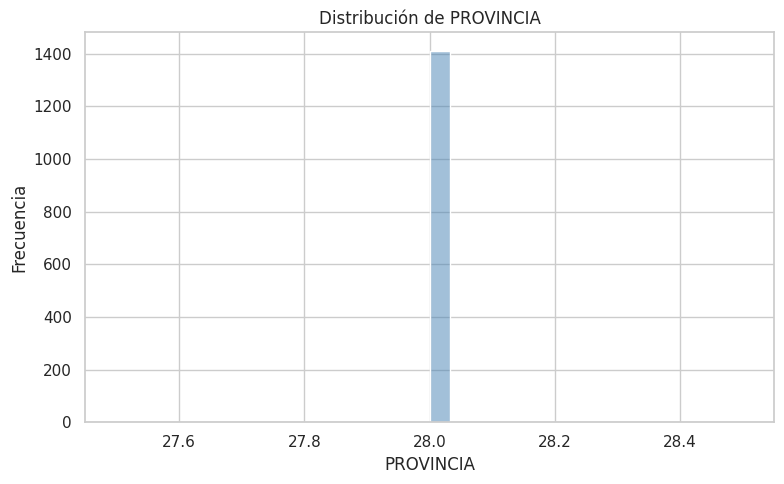

In [14]:
# Histograma de la primera columna numérica disponible
if num_df.shape[1] >= 1:
    col1 = num_df.columns[0]
    plt.figure(figsize=(8, 5))
    sns.histplot(num_df[col1].dropna(), bins=30, kde=True, color='steelblue')
    plt.title(f'Distribución de {col1}')
    plt.xlabel(col1)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()
else:
    print('No hay columnas numéricas suficientes para generar el histograma.')

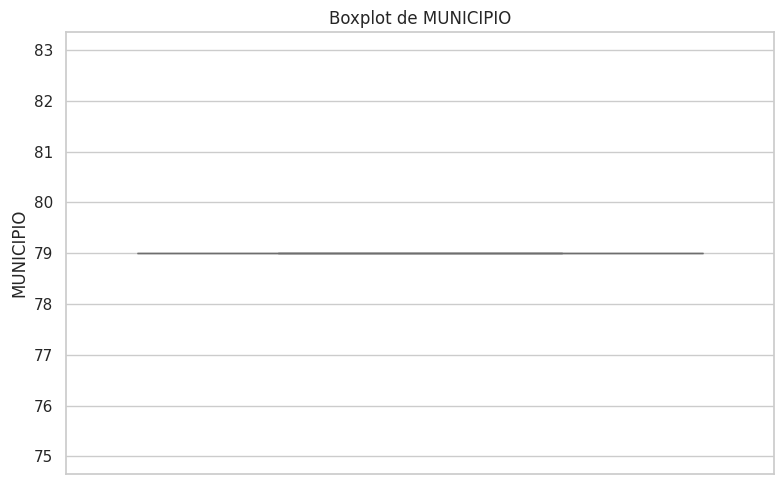

In [15]:
# Boxplot de una segunda columna numérica si existe
if num_df.shape[1] >= 2:
    col2 = num_df.columns[1]
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=num_df[col2].dropna(), color='lightcoral')
    plt.title(f'Boxplot de {col2}')
    plt.ylabel(col2)
    plt.tight_layout()
    plt.show()
else:
    print('No hay una segunda columna numérica para el boxplot.')

#### 9. Objetivo analítico y desarrollo
Dado que el objetivo principal es realizar una exploración crítica y un tratamiento general del dataset, en esta fase se analiza:
- resumen estadístico,
- correlaciones entre variables numéricas,
- variables con mayor dispersión,
- distribución de valores ausentes.

In [16]:
## Estadísticas descriptivas del bloque numérico
if num_df.shape[1] > 0:
    display(num_df.describe().T)
else:
    print('No hay columnas numéricas para mostrar estadísticos descriptivos.')

,count,mean,std,min,25%,50%,75%,max
PROVINCIA,1411.0,28.000000,0.000000,28.0,28.00,28.0,28.0,28.0
MUNICIPIO,1411.0,79.000000,0.000000,79.0,79.00,79.0,79.0,79.0
ESTACION,1411.0,36.060241,18.060770,4.0,18.00,38.0,54.0,60.0
MAGNITUD,1411.0,11.629341,7.020494,1.0,8.00,10.0,12.0,35.0
ANO,1411.0,2024.000000,0.000000,2024.0,2024.00,2024.0,2024.0,2024.0
MES,1411.0,5.989369,3.168421,1.0,3.00,6.0,9.0,11.0
D01,1411.0,20.567824,25.663916,0.0,3.00,11.0,28.0,246.0
D02,1411.0,19.680369,25.500542,0.0,2.00,10.0,25.0,208.0
D03,1411.0,17.686109,22.172894,0.0,2.00,11.0,22.0,157.0
D04,1411.0,20.300354,23.177421,0.0,3.00,12.0,29.0,188.0


In [17]:
# Variables numéricas con mayor variabilidad
if num_df.shape[1] > 0:
    dispersion = num_df.std(numeric_only=True).sort_values(ascending=False)
    dispersion_df = dispersion.reset_index()
    dispersion_df.columns = ['variable', 'desviacion_tipica']
    display(dispersion_df.head(10))
else:
    print('No hay variables numéricas para calcular dispersión.')

,variable,desviacion_tipica
0,D26,32.136833
1,D24,30.891528
2,D25,29.999765
3,D30,29.638498
4,D23,28.774384
5,D05,27.239766
6,D29,27.028926
7,D27,26.891422
8,D28,26.636685
9,D08,25.690206


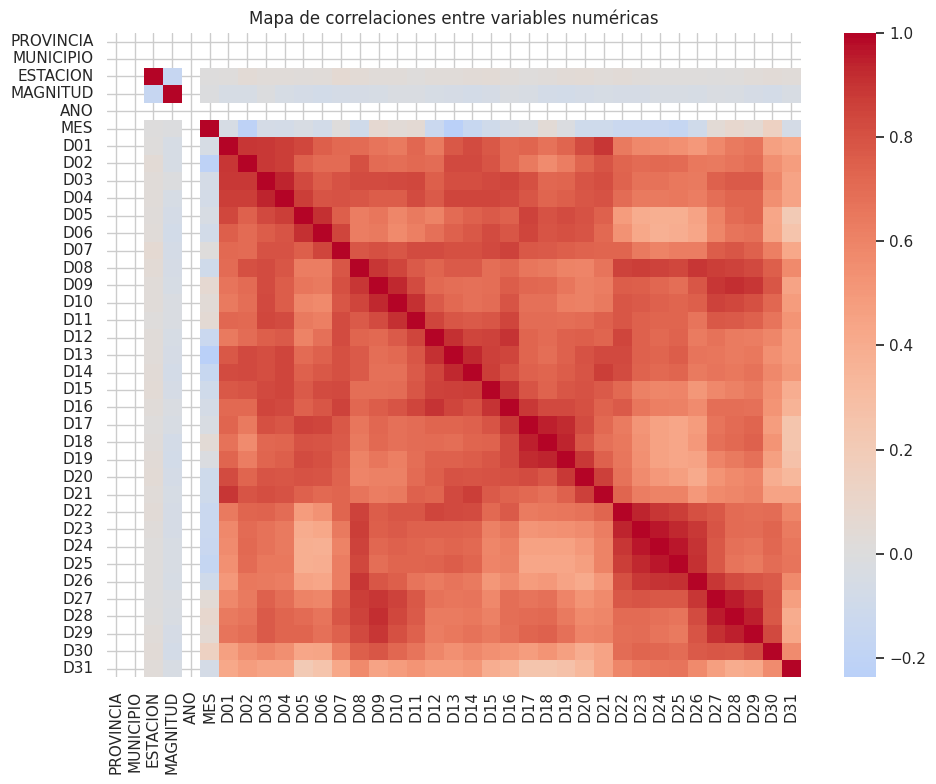

In [18]:
# Mapa de correlaciones (si hay suficientes columnas numéricas)
if num_df.shape[1] >= 2:
    corr = num_df.corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Mapa de correlaciones entre variables numéricas')
    plt.tight_layout()
    plt.show()
else:
    print('No hay columnas numéricas suficientes para calcular correlaciones.')

In [19]:
# Resumen de missing values por porcentaje
missing_plot = missing_table[missing_table['missing_abs'] > 0].head(10).reset_index()
missing_plot.columns = ['variable', 'missing_abs', 'missing_pct']

if not missing_plot.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=missing_plot, x='variable', y='missing_pct', palette='viridis')
    plt.title('Porcentaje de valores ausentes por variable')
    plt.xlabel('Variable')
    plt.ylabel('% missing')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No se han detectado valores ausentes en las primeras variables revisadas.')

No se han detectado valores ausentes en las primeras variables revisadas.


#### 10. Visualización final
Como visualización final se resume el objetivo logrado con un gráfico de las variables numéricas de mayor dispersión, ya que permiten identificar qué dimensiones del dataset presentan mayor variabilidad y, por tanto, mayor interés analítico.

/tmp/ipykernel_2961/265362803.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_disp_df, y='variable', x='desviacion_tipica', palette='magma')


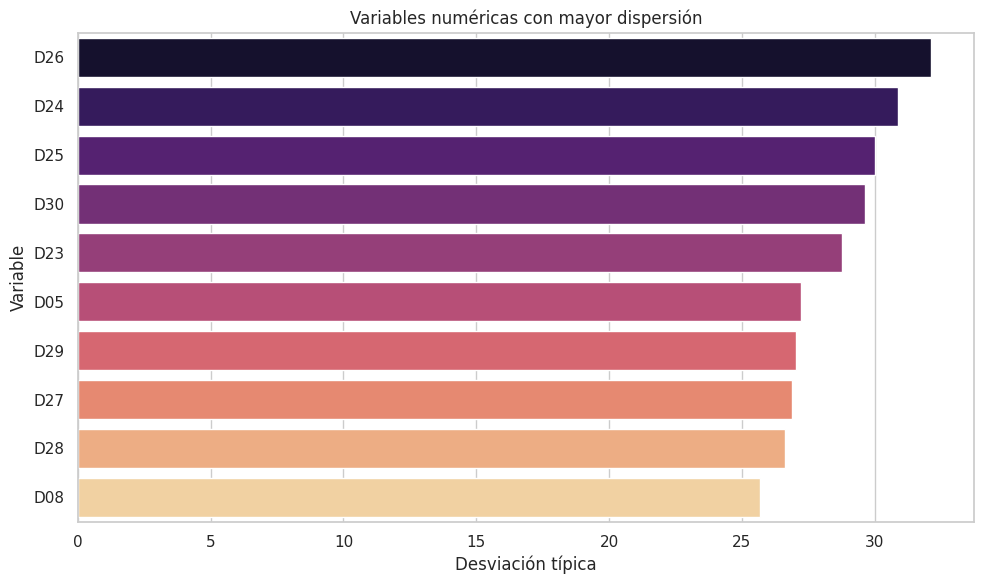

In [20]:
# Visualización final: top variables con mayor desviación típica
if num_df.shape[1] > 0:
    top_disp = num_df.std(numeric_only=True).sort_values(ascending=False).head(10)
    top_disp_df = top_disp.reset_index()
    top_disp_df.columns = ['variable', 'desviacion_tipica']

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_disp_df, y='variable', x='desviacion_tipica', palette='magma')
    plt.title('Variables numéricas con mayor dispersión')
    plt.xlabel('Desviación típica')
    plt.ylabel('Variable')
    plt.tight_layout()
    plt.show()
else:
    print('No hay variables numéricas para la visualización final.')

In [21]:
# Resumen final automático
resumen_final = {
    'filas_iniciales': int(df.shape[0]),
    'columnas_iniciales': int(df.shape[1]),
    'filas_tras_eliminar_duplicados': int(work.shape[0]),
    'num_columnas_numericas': int(num_df.shape[1]),
    'columnas_fecha_detectadas': possible_date_cols,
    'recurso_utilizado': resource_url,
    'encoding_utilizado': encoding_used,
    'separador_utilizado': sep_used
}
resumen_final

{'filas_iniciales': 1411,
 'columnas_iniciales': 69,
 'filas_tras_eliminar_duplicados': 1411,
 'num_columnas_numericas': 37,
 'columnas_fecha_detectadas': [],
 'recurso_utilizado': 'https://datos.madrid.es/dataset/201410-0-calidad-aire-diario/resource/201410-4-calidad-aire-diario-csv/download/201410-4-calidad-aire-diario-csv.csv',
 'encoding_utilizado': 'utf-8-sig',
 'separador_utilizado': ';'}

#### 11. Conclusión y reflexión
Esta actividad permite comprobar que trabajar con datos abiertos reales implica enfrentarse a problemas habituales de análisis de datos: estructuras no siempre homogéneas, formatos de descarga variables, posibles cambios en los recursos del portal, valores ausentes y necesidad de convertir correctamente los tipos.

El principal aprendizaje de este trabajo es que **la preparación del dato es una parte esencial del análisis**. Antes de visualizar o extraer conclusiones, es necesario localizar el recurso correcto, leerlo adecuadamente y validar su estructura. A partir de ahí, herramientas como **Pandas** facilitan la exploración, mientras que **Matplotlib** y **Seaborn** permiten comunicar visualmente los hallazgos.

Además, usar un dataset del Ayuntamiento de Madrid aporta valor a la actividad porque se trabaja con información pública, real y reutilizable, desarrollando también una visión crítica sobre la calidad y utilidad de los datos abiertos.

#### 12. Referencias
- Portal de datos abiertos del Ayuntamiento de Madrid: https://datos.madrid.es/
- Dataset utilizado: https://datos.madrid.es/egob/catalogo/201410-0-calidad-aire-diario